In [1]:
import gradio as gr
import os
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [2]:
from openai import OpenAI
api_key = os.getenv('OPENAI_API_KEY')

if api_key and api_key.startswith('sk-proj-') and len(api_key)>10:
    print("API key looks good so far")
else:
    print("There might be a problem with your API key? Please visit the troubleshooting notebook!")
    
MODEL = 'gpt-5-nano'
openai = OpenAI()

API key looks good so far


In [3]:
system_message=""" You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
don't ask departure city, only arrival city.
Always be accurate. If you don't know the answer, say so."""

In [4]:
price_format_for_llm={
    "name":"ticket_prices",
    "description":"It will give the fare price for destination city for following timeline",
    "parameters":{
            "type":"object",
            "properties": {
                        "destination_city":{ 
                                 "type":"string",
                                  "description":"This is the Destination City for User"
                                },
                         "time":
                                { 
                                 "type":"string",
                                "description":"This is the flight time for User"
                                }

                        },
            "required":["destination_city","time"],
            "additionalProperties": False

}
}

In [5]:
tools=[{"type":"function","function":price_format_for_llm}]
tools

[{'type': 'function',
  'function': {'name': 'ticket_prices',
   'description': 'It will give the fare price for destination city for following timeline',
   'parameters': {'type': 'object',
    'properties': {'destination_city': {'type': 'string',
      'description': 'This is the Destination City for User'},
     'time': {'type': 'string',
      'description': 'This is the flight time for User'}},
    'required': ['destination_city', 'time'],
    'additionalProperties': False}}}]

In [6]:
import json
def tool_manager(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "ticket_prices":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            times=arguments.get('time')
            price_details = ticket_prices(city,times)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses

In [7]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = tool_manager(message)
        messages.append(message)
        messages.extend(responses)
        for item in messages:
            print(item)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
    return response.choices[0].message.content
    

gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7870
* To create a public link, set `share=True` in `launch()`.


In [8]:
import sqlite3

In [9]:
DB = "prices.db"

import sqlite3

with sqlite3.connect(DB) as conn:
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS prices (
            city TEXT NOT NULL,
            time TEXT NOT NULL,
            price REAL NOT NULL,
            PRIMARY KEY (city, time)
        )
    """)
    conn.commit()


In [10]:
def ticket_prices(city, time):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ? AND time = ?', (city.lower(), time.lower()))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]} for time {time}" if result else "No price data available for this city"

In [11]:
def set_ticket_price(city, time,price):
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('INSERT INTO prices (city, time,price) VALUES (?, ?,?) ON CONFLICT(city,time) DO UPDATE SET price = ?', (city.lower(), time.lower(), price, price))
        conn.commit()

In [12]:
tickets= {
    "london": {
        "morning": "$799",
        "afternoon": "$849",
        "evening": "$899",
        "night": "$749"
    },
    "paris": {
        "morning": "$899",
        "afternoon": "$949",
        "evening": "$999",
        "night": "$859"
    },
    "tokyo": {
        "morning": "$1400",
        "afternoon": "$1450",
        "evening": "$1500",
        "night": "$1350"
    },
    "berlin": {
        "morning": "$499",
        "afternoon": "$549",
        "evening": "$599",
        "night": "$469"
    },
    "rome": {
        "morning": "$699",
        "afternoon": "$749",
        "evening": "$799",
        "night": "$659"
    },
    "new york": {
        "morning": "$999",
        "afternoon": "$1049",
        "evening": "$1099",
        "night": "$949"
    }
}

for city, times in tickets.items():
    for time, price in times.items():
        set_ticket_price(city, time, price)

In [13]:
ticket_prices("london","morning")

DATABASE TOOL CALLED: Getting price for london


'Ticket price to london is $$799 for time morning'

In [14]:
import json
def tool_manager(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "ticket_prices":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            times=arguments.get('time')
            price_details = ticket_prices(city,times)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses

In [15]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = tool_manager(message)
        messages.append(message)
        messages.extend(responses)
        for item in messages:
            print(item)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
    return response.choices[0].message.content
    

gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7871
* To create a public link, set `share=True` in `launch()`.


In [16]:
import base64
from io import BytesIO
from PIL import Image

In [17]:
def artist(city):
    image_response = openai.images.generate(
            model="dall-e-3",
            prompt=f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant realistic style",
            size="1024x1024",
            n=1,
            response_format="b64_json",
        )
    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_data))

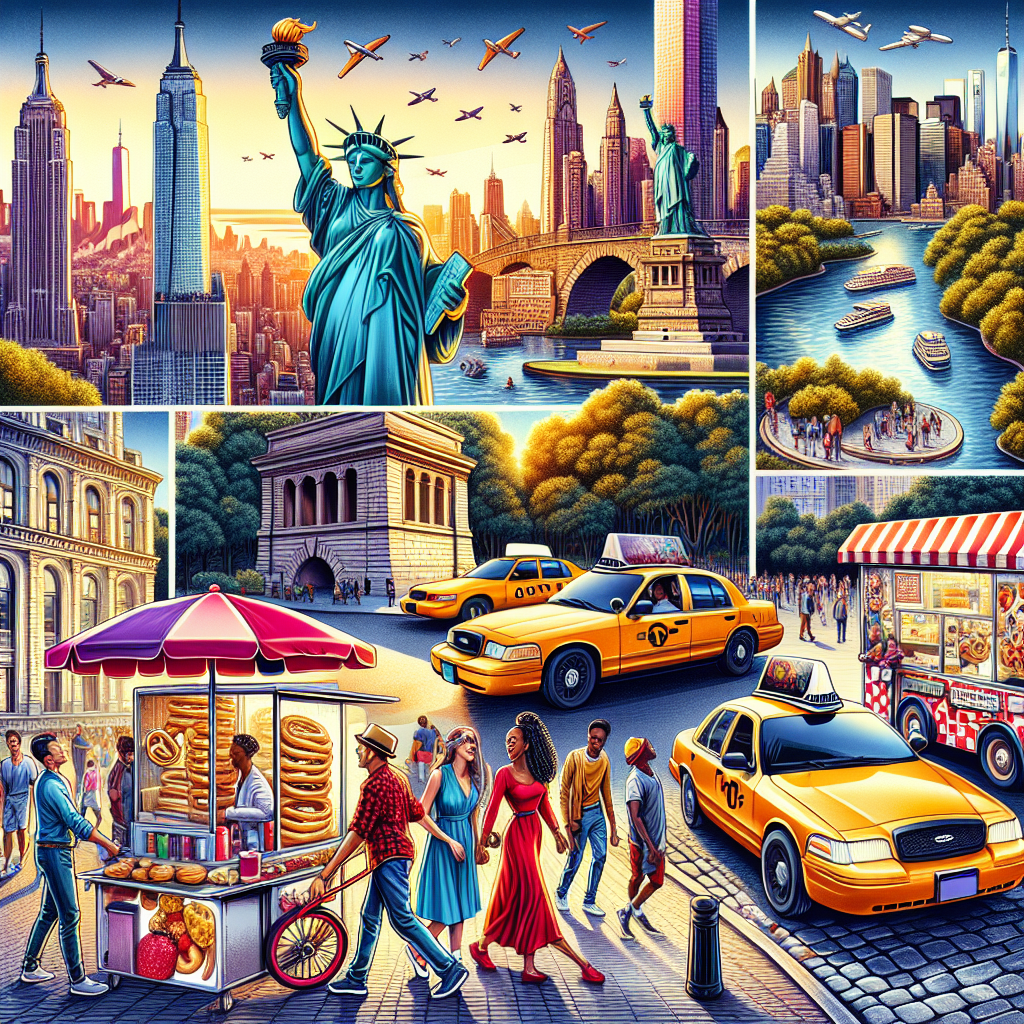

In [18]:
image = artist("New York City")
display(image)

In [19]:
def talker(message):
    response = openai.audio.speech.create(
      model="gpt-4o-mini-tts",
      voice="onyx",    # Also, try replacing onyx with alloy or coral
      input=message
    )
    return response.content

In [20]:
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    cities = []
    image = None

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, cities = tool_manager(message)
        cities.append(city)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    voice = talker(reply)

    if cities:
        image = artist(cities[0])
    
    return history, voice, image


In [21]:
def tool_manager(message):
    responses = []
    cities= []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "ticket_prices":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            times=arguments.get('time')
            cities.append(city)
            price_details = ticket_prices(city,times)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses,cities

In [22]:
def chatbot_Ui(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(chatbot_Ui, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("admin", "admin"), share=True)

* Running on local URL:  http://127.0.0.1:7872
* Running on public URL: https://15817ea6306d3d110f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
